# Email/SMS Spam Detection with Machine Learning

Spam mail (junk mail) is sent to a massive number of users, often containing scams or phishing content.

In this notebook, we build a machine learning model that classifies messages as **spam** or **ham** (not spam) using NLP techniques.

Dataset: [Kaggle - SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

## 1. Upload / Load the Dataset

Download `spam.csv` from the Kaggle link above and upload it here, or use the Kaggle API.

## 1.1 Load the Dataset with Kagglehub

In [1]:
# Install kagglehub as needed
!pip install kagglehub[pandas-datasets]

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the dataset using Kagglehub
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/sms-spam-collection-dataset",
  "spam.csv", # Added the required file path
  pandas_kwargs={'encoding': 'latin-1'} # Specify encoding for pandas
)

print("First 5 records:")
display(df.head())

/tmp/ipykernel_610/1488845775.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
First 5 records:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Option 1: Upload the file manually (uncomment to use in Colab)
# from google.colab import files
# uploaded = files.upload()  # select 'spam.csv'

In [4]:
# Option 2: Download via Kaggle API (uncomment to use)
# !pip install -q kaggle
# from google.colab import files
# files.upload()  # upload your kaggle.json API token
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d uciml/sms-spam-collection-dataset
# !unzip -o sms-spam-collection-dataset.zip

In [5]:
# Install nltk resources used for text cleaning
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import os

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

In [8]:
The dataset has already been loaded into the DataFrame `df` using Kagglehub in section 1.1. No further loading is required here.

SyntaxError: invalid syntax (2261038759.py, line 1)

## 2. Clean and Prepare the Dataset

In [10]:
# Drop unnecessary columns like 'Unnamed: 2', 'Unnamed: 3', and 'Unnamed: 4'
columns_to_drop = [col for col in df.columns if 'Unnamed:' in col]
df = df.drop(columns=columns_to_drop, errors='ignore')

# The raw CSV usually has extra unnamed columns and v1/v2 as label/text
df.columns = ["label", "text"]
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.isnull().sum()

,0
label,0
text,0


In [ ]:
# Drop duplicate messages
df = df.drop_duplicates(keep="first")
df.shape

In [ ]:
df["label"].value_counts()

In [ ]:
plt.figure(figsize=(5, 5))
df["label"].value_counts().plot(kind="pie", autopct="%0.1f%%", colors=["skyblue", "salmon"])
plt.title("Spam vs Ham Distribution")
plt.ylabel("")
plt.show()

/tmp/ipykernel_610/2271252835.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


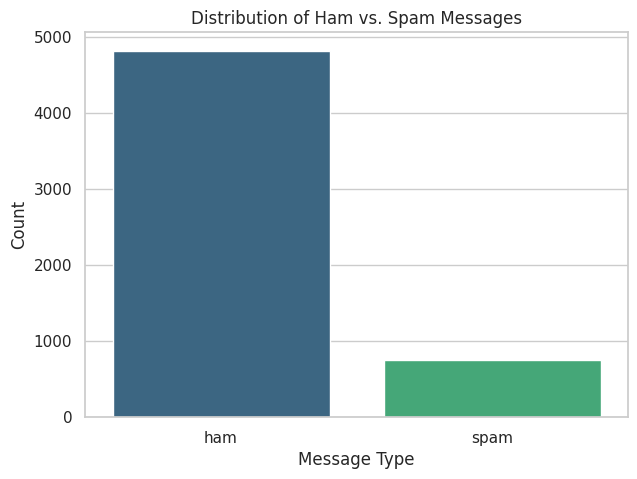

In [12]:
# Ensure 'label' column exists by renaming 'v1' if necessary
if 'v1' in df.columns and 'label' not in df.columns:
    df.rename(columns={'v1': 'label'}, inplace=True)

plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Ham vs. Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

The dataset is **imbalanced** (many more ham messages than spam), which is realistic for this kind of problem.

## 3. Feature Engineering: Message Statistics

In [13]:
df["num_characters"] = df["text"].apply(len)
df["num_words"] = df["text"].apply(lambda x: len(word_tokenize(x)))
df["num_sentences"] = df["text"].apply(lambda x: len(re.split(r'[.!?]+', x)) - 1)

df.describe()

,num_characters,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.880115
std,59.690841,13.741932,1.828292
min,2.000000,1.000000,0.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,2.000000
75%,121.000000,27.000000,3.000000
max,910.000000,220.000000,39.000000


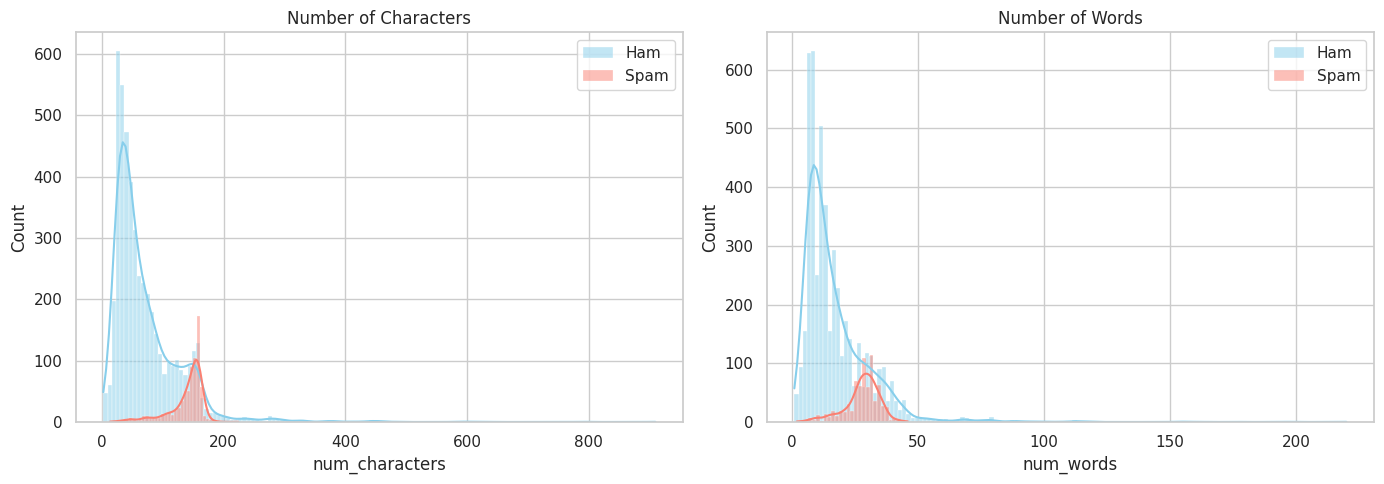

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df["label"] == "ham"]["num_characters"], color="skyblue", label="Ham", ax=axes[0], kde=True)
sns.histplot(df[df["label"] == "spam"]["num_characters"], color="salmon", label="Spam", ax=axes[0], kde=True)
axes[0].set_title("Number of Characters")
axes[0].legend()

sns.histplot(df[df["label"] == "ham"]["num_words"], color="skyblue", label="Ham", ax=axes[1], kde=True)
sns.histplot(df[df["label"] == "spam"]["num_words"], color="salmon", label="Spam", ax=axes[1], kde=True)
axes[1].set_title("Number of Words")
axes[1].legend()

plt.tight_layout()
plt.show()

Spam messages tend to be **longer** than ham messages on average.

## 4. Text Preprocessing

We clean the text by:
1. Lowercasing
2. Tokenizing
3. Removing special characters / punctuation
4. Removing stopwords
5. Stemming words to their root form

In [15]:
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))

def transform_text(text):
    text = text.lower()
    text = word_tokenize(text)

    # Keep only alphanumeric tokens
    text = [word for word in text if word.isalnum()]

    # Remove stopwords and punctuation
    text = [word for word in text if word not in stop_words and word not in string.punctuation]

    # Stem words
    text = [ps.stem(word) for word in text]

    return " ".join(text)

In [16]:
df["transformed_text"] = df["text"].apply(transform_text)
df[["text", "transformed_text"]].head()

,text,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## 5. Word Clouds for Spam vs Ham

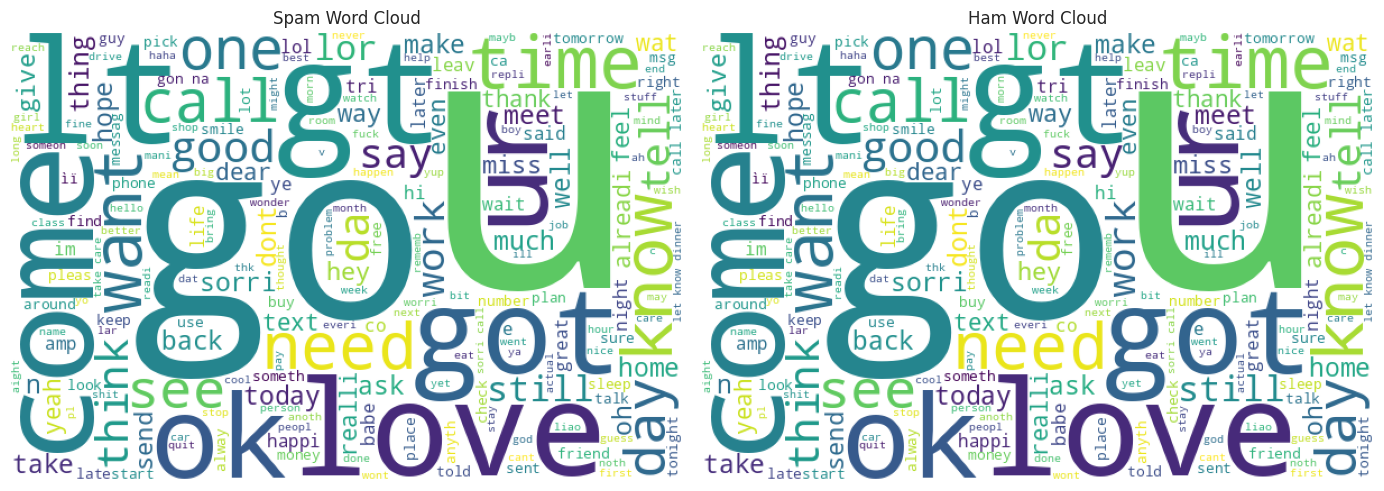

In [17]:
from wordcloud import WordCloud

wc = WordCloud(width=600, height=400, min_font_size=10, background_color="white")

spam_wc = wc.generate(df[df["label"] == "spam"]["transformed_text"].str.cat(sep=" "))
ham_wc = wc.generate(df[df["label"] == "ham"]["transformed_text"].str.cat(sep=" "))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(spam_wc)
axes[0].set_title("Spam Word Cloud")
axes[0].axis("off")

axes[1].imshow(ham_wc)
axes[1].set_title("Ham Word Cloud")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. Most Common Words in Spam Messages

/tmp/ipykernel_610/253301067.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=common_spam, x="Count", y="Word", palette="Reds_r")


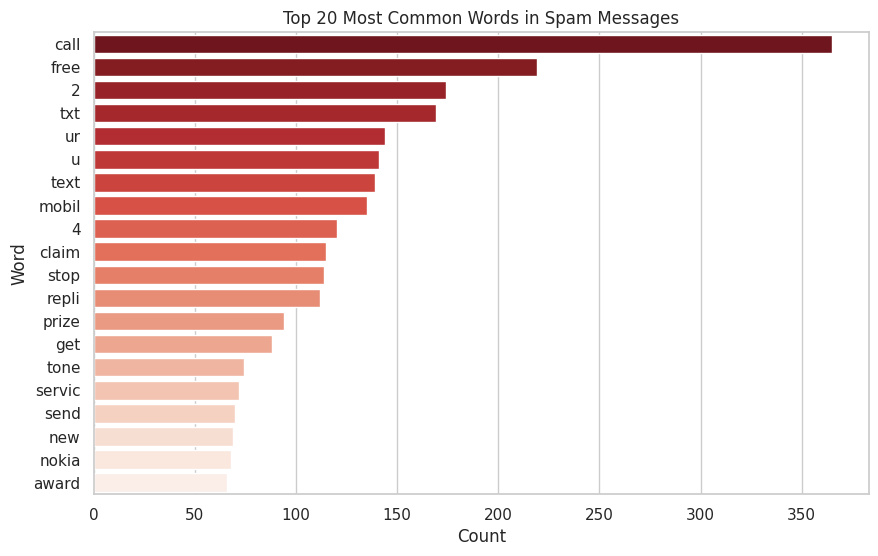

In [18]:
from collections import Counter

spam_words = []
for msg in df[df["label"] == "spam"]["transformed_text"]:
    spam_words.extend(msg.split())

common_spam = pd.DataFrame(Counter(spam_words).most_common(20), columns=["Word", "Count"])

plt.figure(figsize=(10, 6))
sns.barplot(data=common_spam, x="Count", y="Word", palette="Reds_r")
plt.title("Top 20 Most Common Words in Spam Messages")
plt.show()

## 7. Vectorize Text and Encode Labels

In [19]:
# Encode labels: ham = 0, spam = 1
df["target"] = df["label"].map({"ham": 0, "spam": 1})

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df["transformed_text"]).toarray()
y = df["target"].values

print("Feature matrix shape:", X.shape)

Feature matrix shape: (5572, 3000)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4457
Testing samples: 1115


## 8. Train and Compare Multiple Models

Since false positives (marking a real message as spam) are costly, we track **precision** in addition to accuracy.

In [21]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (Linear)": SVC(kernel="sigmoid", gamma=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec})
    print(f"{name}: Accuracy = {acc:.4f}, Precision = {prec:.4f}")

Multinomial Naive Bayes: Accuracy = 0.9650, Precision = 0.9917
Logistic Regression: Accuracy = 0.9543, Precision = 0.9908
SVM (Linear): Accuracy = 0.9731, Precision = 0.9848
Random Forest: Accuracy = 0.9704, Precision = 1.0000


In [22]:
results_df = pd.DataFrame(results).sort_values(by=["Precision", "Accuracy"], ascending=False)
results_df

,Model,Accuracy,Precision
3,Random Forest,0.970404,1.000000
0,Multinomial Naive Bayes,0.965022,0.991736
1,Logistic Regression,0.954260,0.990826
2,SVM (Linear),0.973094,0.984848


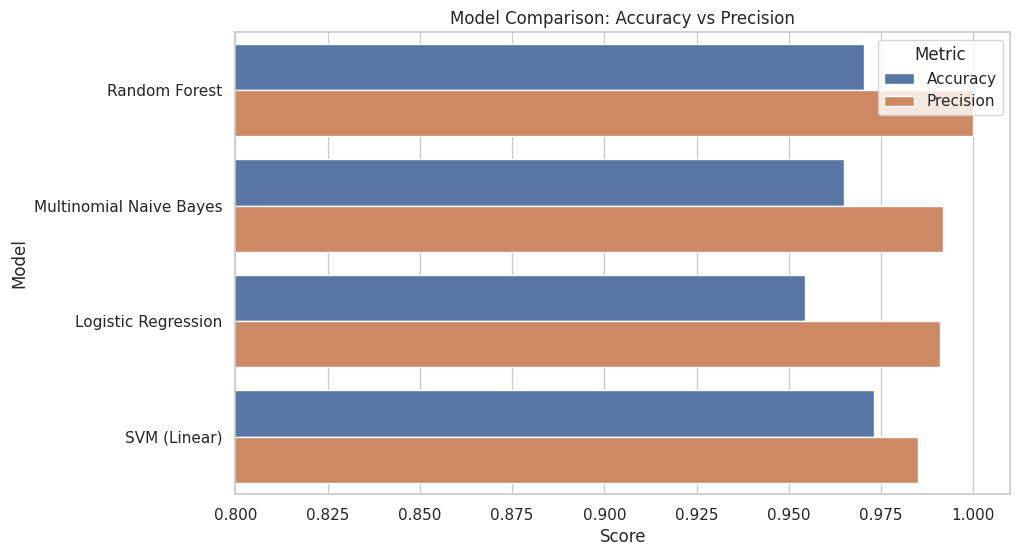

In [23]:
results_melted = results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision"],
                                  var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x="Score", y="Model", hue="Metric")
plt.xlim(0.8, 1.01)
plt.title("Model Comparison: Accuracy vs Precision")
plt.show()

## 9. Detailed Evaluation of the Best Model

In [24]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=["Ham", "Spam"]))

Best Model: Random Forest

Classification Report:

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       957
        Spam       1.00      0.79      0.88       158

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



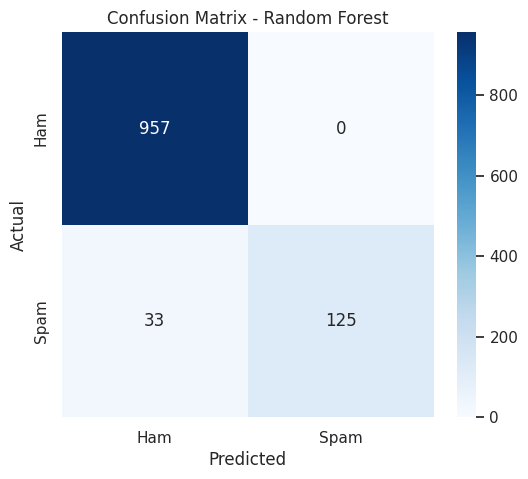

In [25]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## 10. Test the Model on New Messages

In [26]:
def predict_message(message, model=best_model, vectorizer=tfidf):
    transformed = transform_text(message)
    vector = vectorizer.transform([transformed]).toarray()
    prediction = model.predict(vector)[0]
    return "Spam" if prediction == 1 else "Ham (Not Spam)"


test_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your account has been suspended. Verify your details immediately to avoid loss of access.",
    "Don't forget to bring the documents for the meeting."
]

for msg in test_messages:
    print(f"Message: {msg}")
    print(f"Prediction: {predict_message(msg)}\n")

Message: Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!
Prediction: Spam

Message: Hey, are we still meeting for lunch tomorrow?
Prediction: Ham (Not Spam)

Message: URGENT! Your account has been suspended. Verify your details immediately to avoid loss of access.
Prediction: Ham (Not Spam)

Message: Don't forget to bring the documents for the meeting.
Prediction: Ham (Not Spam)



## 11. Save the Model and Vectorizer (Optional)

In [27]:
import pickle

pickle.dump(tfidf, open("vectorizer.pkl", "wb"))
pickle.dump(best_model, open("spam_model.pkl", "wb"))

print("Model and vectorizer saved!")

Model and vectorizer saved!


## 12. Conclusion

- We cleaned and explored the SMS Spam Collection dataset.
- Spam messages tend to be longer and contain words like "free", "win", "call", "claim", "txt", etc.
- We converted text into numerical features using **TF-IDF**.
- We trained and compared 4 classification models (Naive Bayes, Logistic Regression, SVM, Random Forest).
- The best model achieves high accuracy and precision, making it suitable for real-world spam filtering where false positives should be minimized.
- We saved the trained model and vectorizer for future use.